In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<img src="https://drive.google.com/uc?id=18ypjjxs0EJuGVlij-OHlf1VARAgDWMnr" width="800">

# Redução de Churn de Companhia Telefônica #

## 📓 Fase 03 — Data Preparation (continuação) ##

## 🏗️ Engenharia de Atributos e Teste em Modelo Não-Linear ##

### Carregando Bibliotecas ###

In [6]:
#carregando as bibliotecas

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import set_config
set_config(transform_output="pandas")


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)


from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression


### Funções que Vamos Utilizar ###

In [7]:
def criar_confusao(y_true, y_pred, title="Matriz de Confusão"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.xticks([0, 1], ["Não churn (0)", "Churn (1)"])
    plt.yticks([0, 1], ["Não churn (0)", "Churn (1)"])
    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center")
    plt.tight_layout()
    plt.show()


def plot_roc_curves(models: dict, X_test, y_test):
    plt.figure(figsize=(7,5))
    for name, mdl in models.items():
        y_prob = mdl.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc = roc_auc_score(y_test, y_prob)
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("True Positive Rate (TPR)")
    plt.title("Comparação de Curvas ROC")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_pr_curves(models: dict, X_test, y_test):
    plt.figure(figsize=(7,5))
    for name, mdl in models.items():
        y_prob = mdl.predict_proba(X_test)[:, 1]
        precision, recall, _ = precision_recall_curve(y_test, y_prob)
        ap = average_precision_score(y_test, y_prob)
        plt.plot(recall, precision, label=f"{name} (PR-AUC={ap:.3f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Comparação de Curvas Precision-Recall")
    plt.legend()
    plt.tight_layout()
    plt.show()


# ============================================================
#  Feature Engineering encapsulada
# ============================================================
def feature_engineering(X: pd.DataFrame) -> pd.DataFrame:
    X = X.copy()
    if not hasattr(X, "columns"):
        X = pd.DataFrame(X)

    # Temporais
    X["avg_monthly_total_ratio"] = X["total_charges"] / (X["tenure_months"] + 1)
    X["is_new_customer"] = (X["tenure_months"] <= 6).astype(int)
    X["is_loyal_customer"] = (X["tenure_months"] >= 36).astype(int)

    # Insatisfação
    X["complaint_intensity"] = X["complaints_last_3m"] / 3
    X["outage_intensity"] = X["outages_last_3m"] / 3
    X["service_risk_score"] = (
        X["complaints_last_3m"] * 0.6 +
        X["outages_last_3m"] * 0.4
    )

    # Financeiro
    X["financial_risk_score"] = (
        X["late_payments_last_6m"] * 0.7 +
        (X["monthly_charges"] > 80).astype(int) * 0.3
    )
    X["high_discount_flag"] = (X["discount_pct"] > 15).astype(int)

    # Interações
    X["mtm_complaint_flag"] = (
        (X["contract"] == "Month-to-month").astype(int) *
        (X["complaints_last_3m"] > 0).astype(int)
    )
    X["fiber_complaint_flag"] = (
        (X["internet_service"] == "Fiber optic").astype(int) *
        (X["complaints_last_3m"] > 0).astype(int)
    )

    X["risk_density"] = X["service_risk_score"] / (X["tenure_months"] + 1)

    return X

def evaluate_with_threshold(y_true, y_proba, threshold: float):
    y_pred = (y_proba >= threshold).astype(int)

    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, digits=2)

    roc = roc_auc_score(y_true, y_proba)
    pr = average_precision_score(y_true, y_proba)

    return {
        "threshold": threshold,
        "roc_auc": roc,
        "pr_auc": pr,
        "cm": cm,
        "report": report,
        "y_pred": y_pred,
    }

def threshold_sweep(y_true, y_proba, thresholds=None, optimize_for="f1", min_recall=None):
    """
    optimize_for: 'f1' ou 'recall' ou 'precision'
    min_recall: se quiser impor recall mínimo para churn (classe 1)
    """
    if thresholds is None:
        thresholds = np.linspace(0.05, 0.95, 19)

    best = None
    best_score = -np.inf
    history = []

    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        cm = confusion_matrix(y_true, y_pred)
        tn, fp, fn, tp = cm.ravel()

        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall    = tp / (tp + fn) if (tp + fn) else 0.0
        f1        = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0.0

        if min_recall is not None and recall < min_recall:
            score = -np.inf
        else:
            if optimize_for == "f1":
                score = f1
            elif optimize_for == "recall":
                score = recall
            elif optimize_for == "precision":
                score = precision
            else:
                raise ValueError("optimize_for deve ser: 'f1', 'recall' ou 'precision'")

        history.append((t, precision, recall, f1))

        if score > best_score:
            best_score = score
            best = {
                "threshold": t,
                "precision_1": precision,
                "recall_1": recall,
                "f1_1": f1,
                "cm": cm,
            }

    return best, np.array(history, dtype=float)


### Carga do Dataset Original ###

In [8]:
# importando dados do dataset para um dataframe
id_csv = '15QJP30THekn2PabHiDTrdlidcD5cc5Wi'
url_csv = f'https://drive.google.com/uc?id={id_csv}'
df = pd.read_csv(url_csv)

## visualizando o cabeçalho as colunas (nomes dos atributos)
df.columns

Index(['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents',
       'tenure_months', 'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges',
       'complaints_last_3m', 'outages_last_3m', 'avg_download_mbps',
       'late_payments_last_6m', 'promo_active', 'discount_pct', 'churn'],
      dtype='object')

In [9]:
## Formato do dataframe
print("Forma do dataframe (linhas x colunas):")
df.shape

Forma do dataframe (linhas x colunas):


(6000, 27)

### 📊 Dicionário de Dados – Dataset de Clientes (Churn) ###

| # | Categoria | Campo (coluna) | Descrição (PT-BR) |
|---|-----------|----------------|-------------------|
| 1 | Identificação do cliente | `customer_id` | Identificador único do cliente |
| 2 | Perfil demográfico | `gender` | Gênero do cliente |
| 3 | Perfil demográfico | `senior_citizen` | Indica se o cliente é idoso (1 = sim, 0 = não) |
| 4 | Perfil demográfico | `partner` | Indica se o cliente possui parceiro(a) |
| 5 | Perfil demográfico | `dependents` | Indica se o cliente possui dependentes |
| 6 | Relacionamento com a empresa | `tenure_months` | Tempo de relacionamento do cliente com a empresa, em meses |
| 7 | Serviços contratados | `phone_service` | Indica se o cliente possui serviço de telefonia |
| 8 | Serviços contratados | `multiple_lines` | Indica se o cliente possui múltiplas linhas telefônicas |
| 9 | Serviços contratados | `internet_service` | Tipo de serviço de internet contratado (ex.: fibra, DSL, nenhum) |
|10 | Serviços contratados | `online_security` | Indica se o cliente possui serviço de segurança online |
|11 | Serviços contratados | `online_backup` | Indica se o cliente possui serviço de backup online |
|12 | Serviços contratados | `device_protection` | Indica se o cliente possui serviço de proteção de dispositivos |
|13 | Serviços contratados | `tech_support` | Indica se o cliente possui serviço de suporte técnico |
|14 | Serviços contratados | `streaming_tv` | Indica se o cliente possui serviço de streaming de TV |
|15 | Serviços contratados | `streaming_movies` | Indica se o cliente possui serviço de streaming de filmes |
|16 | Contrato e cobrança | `contract` | Tipo de contrato do cliente (mensal, anual ou bienal) |
|17 | Contrato e cobrança | `paperless_billing` | Indica se o cliente utiliza fatura digital (sem papel) |
|18 | Contrato e cobrança | `payment_method` | Forma de pagamento utilizada pelo cliente |
|19 | Contrato e cobrança | `monthly_charges` | Valor mensal cobrado do cliente |
|20 | Contrato e cobrança | `total_charges` | Valor total pago pelo cliente ao longo do relacionamento |
|21 | Qualidade do serviço | `complaints_last_3m` | Número de reclamações nos últimos 3 meses |
|22 | Qualidade do serviço | `outages_last_3m` | Número de falhas ou interrupções nos últimos 3 meses |
|23 | Qualidade do serviço | `avg_download_mbps` | Velocidade média de download do cliente (Mbps) |
|24 | Comportamento financeiro | `late_payments_last_6m` | Número de pagamentos em atraso nos últimos 6 meses |
|25 | Promoções | `promo_active` | Indica se o cliente possui promoção ativa |
|26 | Promoções | `discount_pct` | Percentual de desconto aplicado ao cliente |
|27 | Variável alvo | `churn` | Indica se o cliente cancelou o serviço (1 = cancelou, 0 = permaneceu) |

> **Observação didática:**  
> Este dataset permite construir uma **visão 360° do cliente**, integrando perfil, contrato, uso do serviço, experiência e comportamento financeiro, sendo ideal para estudos de **Data Mining e previsão de churn**.

### 📊 Verificando tipos de valores armazenados ###

In [10]:
## visualizando os dados do dataset
## pode ser apenas df (o nome do dataframe) ou df.head()
df

,customer_id,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,...,payment_method,monthly_charges,total_charges,complaints_last_3m,outages_last_3m,avg_download_mbps,late_payments_last_6m,promo_active,discount_pct,churn
0,C0000001,Male,0,No,No,52,Yes,Yes,Fiber optic,No,...,Mailed check,111.37,5814.37,0,1,209.6,0,Yes,24.0,0
1,C0000002,Female,0,No,Yes,49,Yes,No,DSL,No,...,Electronic check,33.94,1674.85,0,3,41.2,2,No,0.0,0
2,C0000003,Male,0,No,Yes,61,Yes,No,Fiber optic,Yes,...,Bank transfer (automatic),101.19,6167.86,2,0,173.4,0,No,0.0,0
3,C0000004,Male,0,Yes,No,6,Yes,Yes,DSL,No,...,Electronic check,77.53,444.59,1,0,34.8,2,No,0.0,0
4,C0000005,Female,0,No,Yes,23,Yes,Yes,Fiber optic,No,...,Mailed check,67.96,1541.46,0,1,222.3,0,No,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,C0005996,Female,0,No,No,11,Yes,No,No,No internet service,...,Credit card (automatic),37.33,414.38,0,0,0.0,0,Yes,12.5,0
5996,C0005997,Male,0,Yes,No,15,Yes,No,No,No internet service,...,Bank transfer (automatic),18.00,250.89,1,2,0.0,0,No,0.0,0
5997,C0005998,Male,0,Yes,Yes,6,Yes,No,Fiber optic,Yes,...,Mailed check,77.56,528.06,0,0,104.2,1,No,0.0,0
5998,C0005999,Male,0,Yes,No,11,Yes,No,DSL,No,...,Bank transfer (automatic),49.86,521.75,0,0,17.1,0,No,0.0,0


---
Alguns dos passos a seguir já foram vistos antes, portanto, não necessitam maiores explicações.

## 1. Separar Target e Features ##

In [11]:
# retirando as colunas customer_id e churn e atribuindo novo dataset à variável X
X = df.drop(columns=["customer_id", "churn"])

# separando a coluna target "churn" e atribuindo à variável y
y = df["churn"]

## 2. Identificar corretamente os tipos de colunas ##

In [12]:
## anteriormente ['senior_citizen'] foi considerado numérico embora seja categórica provavelmente porque o pandas
## vê como int64, float64 ou bool, portanto, vou converter o tipo para categórico para podermos tratar corretamente os dados
## Você pode testar usando: X['senior_citizen'].unique()

X["senior_citizen"] = X["senior_citizen"].astype("category")

# # categorias armazenadas como texto

cat_cols = X.select_dtypes(include=["object", "category", "string"]).columns.tolist()


# exclude="object" Seleciona dados que não é do tipo object (texto).
# Ou seja:
# #inteiros (int)
# #floats (float)


num_cols = X.select_dtypes(exclude=["object", "category", "string"]).columns.tolist()



#### Conferindo Colunas Categóricas ###

In [13]:
#################################################
# Gera uma tabela de informações sobre as colunas
#################################################
#df_info = pd.DataFrame({
#    "coluna": cat_cols,
#    "dtype": [X[col].dtype for col in cat_cols],
#    "n_unique": [X[col].nunique() for col in cat_cols],
#    "tem_nulos": [X[col].isnull().any() for col in cat_cols]
#})



###############################################################
# Gera uma tabela de informações sobre frequencia de valores
###############################################################
#df_freq = pd.concat(
#    [X[col].value_counts(dropna=False).rename(col) for col in cat_cols],
#    axis=1
#)

resumo = []

for col in cat_cols:

    n_unique = X[col].nunique()

    # Definindo se mostra tudo ou só top 10
    if n_unique <= 20:
        valores = X[col].value_counts(dropna=False).to_dict()
    else:
        valores = X[col].value_counts(dropna=False).head(10).to_dict()

    resumo.append({
        "coluna": col,
        "dtype": X[col].dtype,
        "n_unique": n_unique,
        "tem_nulos": X[col].isnull().any(),
        "valores_freq": valores
    })

df_resumo = pd.DataFrame(resumo)

df_resumo


,coluna,dtype,n_unique,tem_nulos,valores_freq
0,gender,object,2,False,"{'Male': 3012, 'Female': 2988}"
1,senior_citizen,category,2,False,"{0: 5061, 1: 939}"
2,partner,object,2,False,"{'No': 3317, 'Yes': 2683}"
3,dependents,object,2,False,"{'No': 4156, 'Yes': 1844}"
4,phone_service,object,2,False,"{'Yes': 5394, 'No': 606}"
5,multiple_lines,object,3,False,"{'No': 2947, 'Yes': 2447, 'No phone service': ..."
6,internet_service,object,3,False,"{'Fiber optic': 2757, 'DSL': 2035, 'No': 1208}"
7,online_security,object,3,False,"{'No': 3261, 'Yes': 1531, 'No internet service..."
8,online_backup,object,3,False,"{'No': 3049, 'Yes': 1743, 'No internet service..."
9,device_protection,object,3,False,"{'No': 3184, 'Yes': 1608, 'No internet service..."


#### Conferindo Colunas Numéricas ###

In [14]:
num_cols

['tenure_months',
 'monthly_charges',
 'total_charges',
 'complaints_last_3m',
 'outages_last_3m',
 'avg_download_mbps',
 'late_payments_last_6m',
 'discount_pct']

In [15]:
X[num_cols]

,tenure_months,monthly_charges,total_charges,complaints_last_3m,outages_last_3m,avg_download_mbps,late_payments_last_6m,discount_pct
0,52,111.37,5814.37,0,1,209.6,0,24.0
1,49,33.94,1674.85,0,3,41.2,2,0.0
2,61,101.19,6167.86,2,0,173.4,0,0.0
3,6,77.53,444.59,1,0,34.8,2,0.0
4,23,67.96,1541.46,0,1,222.3,0,0.0
...,...,...,...,...,...,...,...,...
5995,11,37.33,414.38,0,0,0.0,0,12.5
5996,15,18.00,250.89,1,2,0.0,0,0.0
5997,6,77.56,528.06,0,0,104.2,1,0.0
5998,11,49.86,521.75,0,0,17.1,0,0.0


### ✅ Colunas devidamente identificadas podemos prosseguir ###

1️⃣ Fazer o split

2️⃣ Criar features que dependem de estatística usando só treino

3️⃣ Aplicar no teste com valor fixo aprendido no treino

---
## 3. Split Estratificado (ANTES de qualquer feature engineering) ##


In [16]:
# ============================================================
# Split (ANTES de qualquer feature engineering)
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

---
## 4. Engenharia de Atributos (Feature engineering)  ##

**💡 Insight importante**

Feature engineering:

> 🚨 Não é tirar variável porque correlação é 0.1

É:

> 👉 Criar variáveis que capturem comportamento.



**Em churn de telecom, três grupos funcionam muito bem:**

- 🔥 Comportamento

- 💰 Financeiro

- ⏳ Temporal

**Engenharia faz sentido de negócio:**

✔ complaint_intensity

✔ service_risk_score

✔ mtm_complaint_flag

✔ fiber_complaint_flag

✔ financial_risk_score

Isso é engenharia comportamental, não só matemática.

**📈 Aplicando a Feature Engineering**


In [17]:

# uso da função  feature_engineering criada anteriormente
# cria as colunas citadas acima

X_train_fe = feature_engineering(X_train)
X_test_fe  = feature_engineering(X_test)

# Checagem de consistência (evita bugs silenciosos)
missing_in_test = set(X_train_fe.columns) - set(X_test_fe.columns)
extra_in_test   = set(X_test_fe.columns)  - set(X_train_fe.columns)
if missing_in_test or extra_in_test:
    raise ValueError(
        f"Inconsistência nas colunas após feature_engineering.\n"
        f"Faltando no teste: {missing_in_test}\n"
        f"Sobrando no teste: {extra_in_test}"
    )

cat_cols = X_train_fe.select_dtypes(include=["object", "category", "string"]).columns.tolist()
num_cols = X_train_fe.select_dtypes(include=["number", "bool"]).columns.tolist()

print("Colunas categóricas:")
cat_cols


Colunas categóricas:


['gender',
 'senior_citizen',
 'partner',
 'dependents',
 'phone_service',
 'multiple_lines',
 'internet_service',
 'online_security',
 'online_backup',
 'device_protection',
 'tech_support',
 'streaming_tv',
 'streaming_movies',
 'contract',
 'paperless_billing',
 'payment_method',
 'promo_active']

In [18]:

print("Colunas numéricas atualizadas:")
num_cols

Colunas numéricas atualizadas:


['tenure_months',
 'monthly_charges',
 'total_charges',
 'complaints_last_3m',
 'outages_last_3m',
 'avg_download_mbps',
 'late_payments_last_6m',
 'discount_pct',
 'avg_monthly_total_ratio',
 'is_new_customer',
 'is_loyal_customer',
 'complaint_intensity',
 'outage_intensity',
 'service_risk_score',
 'financial_risk_score',
 'high_discount_flag',
 'mtm_complaint_flag',
 'fiber_complaint_flag',
 'risk_density']

## 5. Preprocessamento   ##

In [19]:
# ============================================================
#  Preprocessamento
# ============================================================
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])
preprocessor.set_output(transform="pandas")



ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['tenure_months', 'monthly_charges',
                                  'total_charges', 'complaints_last_3m',
                                  'outages_last_3m', 'avg_download_mbps',
                                  'late_payments_last_6m', 'discount_pct',
                                  'avg_monthly_total_ratio', 'is_new_customer',
                                  'is_loyal_customer', 'complaint_intensity',
                                  'outage_inten...
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['gender', 'senior_citizen', 'partner',
                                  'dependents', 'phone_service',
                                  'multiple_lines', 'internet_service',
                                  'online_security', 'online_backup',
                                  'device_protection', 'tech_support',
                                  'streaming_tv', 'streaming_movies',
                                  'contract', 'paperless_billing',
                                  'payment_method', 'promo_active'])])

## 6. Modelo LightGBM   ##

In [20]:
# ============================================================
#  Modelo LightGBM
# ============================================================

feature_transformer = FunctionTransformer(feature_engineering, validate=False)

model_lgb = Pipeline([
    ("feature_engineering", feature_transformer),
    ("preprocess", preprocessor),
    ("classifier", LGBMClassifier(
        n_estimators=600,
        learning_rate=0.03,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight="balanced",
        random_state=42,
        deterministic=True,
        force_row_wise=True,
        n_jobs=1
    ))
])



## 7. Treinar   ##

In [21]:
# força saída numpy no pipeline inteiro

# import warnings

# warnings.filterwarnings(
#     "ignore",
#     message=r"X does not have valid feature names, but LGBMClassifier was fitted with feature names",
#)

model_lgb.fit(X_train, y_train)

y_prob = model_lgb.predict_proba(X_test)[:, 1]

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 590, number of negative: 3610
[LightGBM] [Info] Total Bins 1684
[LightGBM] [Info] Number of data points in the train set: 4200, number of used features: 64
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


## 8. Avaliação   ##

ROC-AUC: 0.7080924190898614
PR-AUC: 0.28181370855536475

Classification Report (Threshold = 0.25)

              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1547
           1       0.25      0.59      0.35       253

    accuracy                           0.69      1800
   macro avg       0.58      0.65      0.57      1800
weighted avg       0.82      0.69      0.73      1800



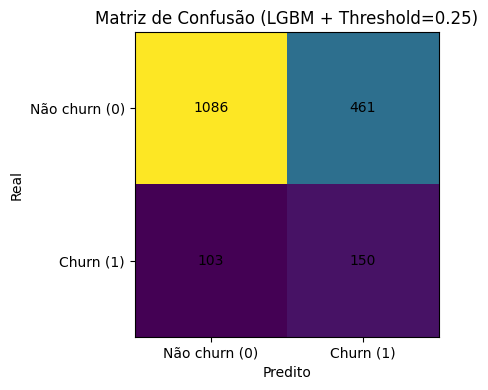

In [22]:
# ============================================================
# Avaliação
# ============================================================

print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("PR-AUC:", average_precision_score(y_test, y_prob))

threshold = 0.25
y_pred = (y_prob >= threshold).astype(int)

print("\nClassification Report (Threshold = 0.25)\n")
print(classification_report(y_test, y_pred))

criar_confusao(y_test, y_pred, title="Matriz de Confusão (LGBM + Threshold=0.25)")

=== Logistic Regression (balanced) ===
ROC-AUC: 0.742848
PR-AUC : 0.331207

=== Melhor threshold (LogReg) ===
threshold  : 0.575
precision_1: 0.305
recall_1   : 0.573
f1_1       : 0.398
Confusion Matrix [ [TN FP], [FN TP] ]:
[[1217  330]
 [ 108  145]]

=== Classification report (threshold ótimo) ===
              precision    recall  f1-score   support

           0       0.92      0.79      0.85      1547
           1       0.31      0.57      0.40       253

    accuracy                           0.76      1800
   macro avg       0.61      0.68      0.62      1800
weighted avg       0.83      0.76      0.78      1800



<Figure size 640x480 with 0 Axes>

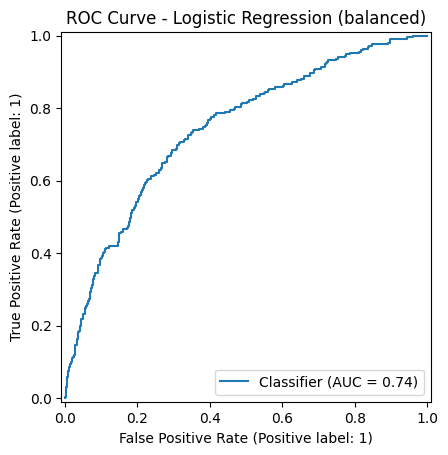

<Figure size 640x480 with 0 Axes>

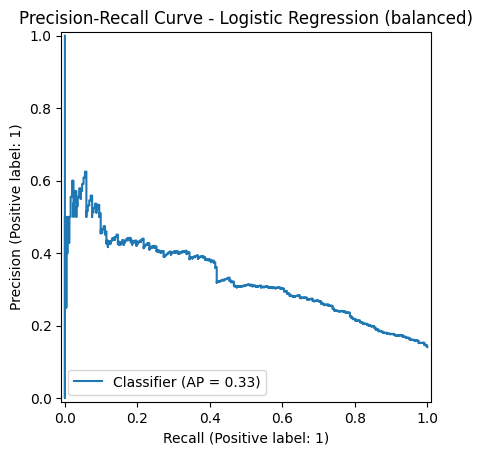

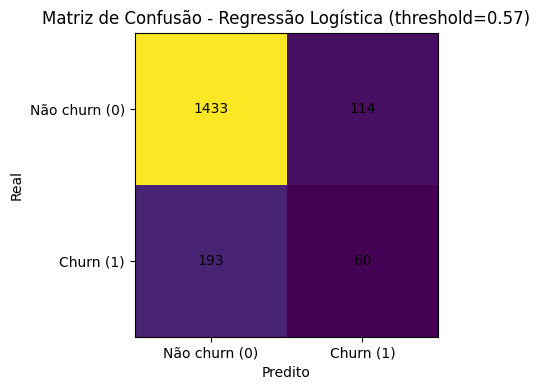

In [29]:
# ============================================================
# Reavaliação pós-LightGBM: Logistic Regression + threshold tuning
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

# -----------------------------
#  Pré-processamento robusto (imputação + one-hot + scale)
# -----------------------------
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())   # ← ESSENCIAL para Regressão logística
])
categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

feature_transformer = FunctionTransformer(feature_engineering, validate=False)

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols),
])

model_lr = Pipeline([
    ("feature_engineering", feature_transformer),  # <- TEM que vir antes
    ("preprocess", preprocessor),
    ("classifier", LogisticRegression(max_iter=5000, class_weight="balanced"))
])

model_lr.fit(X_train, y_train)

# -----------------------------
# 4) Treino + probabilidades
# -----------------------------
model_lr.fit(X_train, y_train)
y_proba_lr = model_lr.predict_proba(X_test)[:, 1]

# Métricas threshold-free
roc_lr = roc_auc_score(y_test, y_proba_lr)
pr_lr  = average_precision_score(y_test, y_proba_lr)

print("=== Logistic Regression (balanced) ===")
print(f"ROC-AUC: {roc_lr:.6f}")
print(f"PR-AUC : {pr_lr:.6f}")

# -----------------------------
# 5) Escolher o melhor threshold
#    - optimize_for='f1' (equilíbrio)
#    - ou 'recall' (agressivo)
#    - e opcionalmente: min_recall=0.60 por exemplo
# -----------------------------
best, hist = threshold_sweep(
    y_true=y_test,
    y_proba=y_proba_lr,
    thresholds=np.linspace(0.05, 0.95, 37),  # varredura mais fina
    optimize_for="f1",
    min_recall=None  # ex: 0.60 para garantir recall mínimo no churn
)

print("\n=== Melhor threshold (LogReg) ===")
print(f"threshold  : {best['threshold']:.3f}")
print(f"precision_1: {best['precision_1']:.3f}")
print(f"recall_1   : {best['recall_1']:.3f}")
print(f"f1_1       : {best['f1_1']:.3f}")
print("Confusion Matrix [ [TN FP], [FN TP] ]:")
print(best["cm"])

# Avaliação detalhada no threshold ótimo
res = evaluate_with_threshold(y_test, y_proba_lr, best["threshold"])
print("\n=== Classification report (threshold ótimo) ===")
print(res["report"])

# -----------------------------
# 6) Plot ROC e Precision-Recall
# -----------------------------
plt.figure()
RocCurveDisplay.from_predictions(y_test, y_proba_lr)
plt.title("ROC Curve - Logistic Regression (balanced)")
plt.show()

plt.figure()
PrecisionRecallDisplay.from_predictions(y_test, y_proba_lr)
plt.title("Precision-Recall Curve - Logistic Regression (balanced)")
plt.show()

# -----------------------------
# 7) Plot Matriz de Confusão (threshold ótimo)
# -----------------------------
y_pred = (y_prob >= best['threshold']).astype(int)

criar_confusao(y_test, y_pred, title=f"Matriz de Confusão - Regressão Logística (threshold={best['threshold']:.2f})")



# -----------------------------
# 8) (Opcional) Comparar com LGBM no mesmo gráfico
#    Se você tiver y_proba_lgbm, ative abaixo:
# -----------------------------
# y_proba_lgbm = ...  # preencha com as probabilidades do seu LGBM no mesmo X_test
# plt.figure()
# RocCurveDisplay.from_predictions(y_test, y_proba_lr, name="LogReg")
# RocCurveDisplay.from_predictions(y_test, y_proba_lgbm, name="LGBM")
# plt.title("ROC - Comparação LogReg vs LGBM")
# plt.show()
#
# plt.figure()
# PrecisionRecallDisplay.from_predictions(y_test, y_proba_lr, name="LogReg")
# PrecisionRecallDisplay.from_predictions(y_test, y_proba_lgbm, name="LGBM")
# plt.title("PR - Comparação LogReg vs LGBM")
# plt.show()

---
## Verificando os dados que foram processados ##

In [24]:
X_temp = feature_engineering(X_train.copy())
X_temp.columns.tolist()

['gender',
 'senior_citizen',
 'partner',
 'dependents',
 'tenure_months',
 'phone_service',
 'multiple_lines',
 'internet_service',
 'online_security',
 'online_backup',
 'device_protection',
 'tech_support',
 'streaming_tv',
 'streaming_movies',
 'contract',
 'paperless_billing',
 'payment_method',
 'monthly_charges',
 'total_charges',
 'complaints_last_3m',
 'outages_last_3m',
 'avg_download_mbps',
 'late_payments_last_6m',
 'promo_active',
 'discount_pct',
 'avg_monthly_total_ratio',
 'is_new_customer',
 'is_loyal_customer',
 'complaint_intensity',
 'outage_intensity',
 'service_risk_score',
 'financial_risk_score',
 'high_discount_flag',
 'mtm_complaint_flag',
 'fiber_complaint_flag',
 'risk_density']

In [25]:
num_cols

['tenure_months',
 'monthly_charges',
 'total_charges',
 'complaints_last_3m',
 'outages_last_3m',
 'avg_download_mbps',
 'late_payments_last_6m',
 'discount_pct',
 'avg_monthly_total_ratio',
 'is_new_customer',
 'is_loyal_customer',
 'complaint_intensity',
 'outage_intensity',
 'service_risk_score',
 'financial_risk_score',
 'high_discount_flag',
 'mtm_complaint_flag',
 'fiber_complaint_flag',
 'risk_density']

In [26]:
cat_cols

['gender',
 'senior_citizen',
 'partner',
 'dependents',
 'phone_service',
 'multiple_lines',
 'internet_service',
 'online_security',
 'online_backup',
 'device_protection',
 'tech_support',
 'streaming_tv',
 'streaming_movies',
 'contract',
 'paperless_billing',
 'payment_method',
 'promo_active']

In [27]:
set(X_temp.columns) - set(num_cols) - set(cat_cols)

set()

Isso confirma:

✔ Nenhuma feature está sendo descartada.

✔ O pipeline está correto.

✔ As novas features entram no modelo.

Então o problema não é técnico.
É estrutural.


### ✅ As novas colunas realmente foram incuídas ###

Entretanto, não agregaram valor:

> Provaelmente por apresentar **forte correlação** com as variáveis já existentes e não agregando capacidade de classificação ao modelo de Regressão logística.

**Vamos testar:**

In [28]:
corr = pd.DataFrame(X_temp[num_cols]).corr().abs()

# remove diagonal
corr_no_diag = corr.where(~np.eye(corr.shape[0], dtype=bool))

# pega pares com correlação alta
high_corr = (
    corr_no_diag.stack()
    .sort_values(ascending=False)
    .head(20)
)

high_corr

,,0
outages_last_3m,outage_intensity,1.000000
outage_intensity,outages_last_3m,1.000000
complaint_intensity,complaints_last_3m,1.000000
complaints_last_3m,complaint_intensity,1.000000
financial_risk_score,late_payments_last_6m,0.955243
late_payments_last_6m,financial_risk_score,0.955243
tenure_months,is_loyal_customer,0.882500
is_loyal_customer,tenure_months,0.882500
avg_monthly_total_ratio,monthly_charges,0.878314
monthly_charges,avg_monthly_total_ratio,0.878314


### 🚨 Diagnóstico Confirmado: Forte Multicolinearidade ###

Olha esses pares:

- Correlação perfeita (1.00)

- outages_last_3m ↔ outage_intensity

- complaints_last_3m ↔ complaint_intensity

👉 Isso significa que uma é basicamente cópia/escala da outra.

A regressão logística não ganha nada adicionando variável duplicada


Correlação altíssima (~0.95)

- financial_risk_score ↔ late_payments_last_6m

De novo: praticamente mesma informação.

Correlação alta (~0.88)

- tenure_months ↔ is_loyal_customer

- monthly_charges ↔ avg_monthly_total_ratio

Provavelmente derivadas.


Correlação 0.82–0.84

- service_risk_score ↔ complaint_intensity

- total_charges ↔ tenure_months

Tudo muito redundante.

---

<div style="text-align: center; margin-top: 20px;">
    <a href="https://colab.research.google.com/drive/1QHAvytCYiw4QO1y_Ak2WNFIdoMMZqNk4"
       style="background-color: #F9AB00; color: white; padding: 12px 24px; text-decoration: none; border-radius: 4px; font-weight: bold; font-family: sans-serif;">
       IR PARA FASE 03 - DATA PREPARATION (CONTINUAÇÃO) - Teste Final de Modelo →
    </a>
</div>